In [2]:
!pip install opencv-python scikit-learn scikit-image matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os

dataset_path = r"C:\Users\Lenovo\OneDrive\Desktop\cyber 5"

print("Dataset path:")
print(dataset_path)

print("\nContents:")
print(os.listdir(dataset_path))

Dataset path:
C:\Users\Lenovo\OneDrive\Desktop\cyber 5

Contents:
['test', 'train']


In [4]:
train_real_path = os.path.join(dataset_path, "train", "Real")
train_fake_path = os.path.join(dataset_path, "train", "Fake")

test_real_path = os.path.join(dataset_path, "test", "Real")
test_fake_path = os.path.join(dataset_path, "test", "Fake")

In [5]:
print("Train Real:")
print(os.listdir(train_real_path))

print("\nTrain Fake:")
print(os.listdir(train_fake_path))

print("\nTest Real:")
print(os.listdir(test_real_path))

print("\nTest Fake:")
print(os.listdir(test_fake_path))

Train Real:
['0000 (10).jpg', '0000 (2).jpg', '0000 (3).jpg', '0000 (4).jpg', '0000 (5).jpg', '0000 (6).jpg', '0000 (7).jpg', '0000 (8).jpg', '0000 (9).jpg', '0000.jpg', '0001 (10).jpg', '0001 (2).jpg', '0001 (3).jpg', '0001 (4).jpg', '0001 (5).jpg', '0001 (6).jpg', '0001 (7).jpg', '0001 (8).jpg', '0001 (9).jpg', '0001.jpg']

Train Fake:
['1000 (10).jpg', '1000 (2).jpg', '1000 (3).jpg', '1000 (4).jpg', '1000 (5).jpg', '1000 (6).jpg', '1000 (7).jpg', '1000 (8).jpg', '1000 (9).jpg', '1000.jpg', '1001 (10).jpg', '1001 (2).jpg', '1001 (3).jpg', '1001 (4).jpg', '1001 (5).jpg', '1001 (6).jpg', '1001 (7).jpg', '1001 (8).jpg', '1001 (9).jpg', '1001.jpg']

Test Real:
['0000 (10).jpg', '0000 (2).jpg', '0000 (3).jpg', '0000 (4).jpg', '0000 (5).jpg', '0000 (6).jpg', '0000 (7).jpg', '0000 (8).jpg', '0000 (9).jpg', '0000.jpg', '0001 (10).jpg', '0001 (2).jpg', '0001 (3).jpg', '0001 (4).jpg', '0001 (5).jpg', '0001 (6).jpg', '0001 (7).jpg', '0001 (8).jpg', '0001 (9).jpg', '0001.jpg', '0002.jpg']

Test 

In [6]:
print("Training Real:", len(os.listdir(train_real_path)))
print("Training Fake:", len(os.listdir(train_fake_path)))

print("Testing Real :", len(os.listdir(test_real_path)))
print("Testing Fake :", len(os.listdir(test_fake_path)))

Training Real: 20
Training Fake: 20
Testing Real : 21
Testing Fake : 20


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [8]:
IMG_SIZE = (128, 128)

def preprocess_image(image_path):
    
    image = cv2.imread(image_path)
    
    if image is None:
        return None
    
    # Resize image
    image = cv2.resize(image, IMG_SIZE)
    
    # Convert BGR to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    return gray

In [9]:
X_train_images = []
y_train = []

# Load Real training images
for filename in os.listdir(train_real_path):
    
    image_path = os.path.join(train_real_path, filename)
    
    image = preprocess_image(image_path)
    
    if image is not None:
        X_train_images.append(image)
        y_train.append(0)


# Load Fake training images
for filename in os.listdir(train_fake_path):
    
    image_path = os.path.join(train_fake_path, filename)
    
    image = preprocess_image(image_path)
    
    if image is not None:
        X_train_images.append(image)
        y_train.append(1)


print("Training images:", len(X_train_images))
print("Training labels:", len(y_train))

print("Real training images:", y_train.count(0))
print("Fake training images:", y_train.count(1))

Training images: 40
Training labels: 40
Real training images: 20
Fake training images: 20


In [10]:
X_test_images = []
y_test = []

# Load Real testing images
for filename in os.listdir(test_real_path):
    
    image_path = os.path.join(test_real_path, filename)
    
    image = preprocess_image(image_path)
    
    if image is not None:
        X_test_images.append(image)
        y_test.append(0)


# Load Fake testing images
for filename in os.listdir(test_fake_path):
    
    image_path = os.path.join(test_fake_path, filename)
    
    image = preprocess_image(image_path)
    
    if image is not None:
        X_test_images.append(image)
        y_test.append(1)


print("Testing images:", len(X_test_images))
print("Testing labels:", len(y_test))

print("Real testing images:", y_test.count(0))
print("Fake testing images:", y_test.count(1))

Testing images: 41
Testing labels: 41
Real testing images: 21
Fake testing images: 20


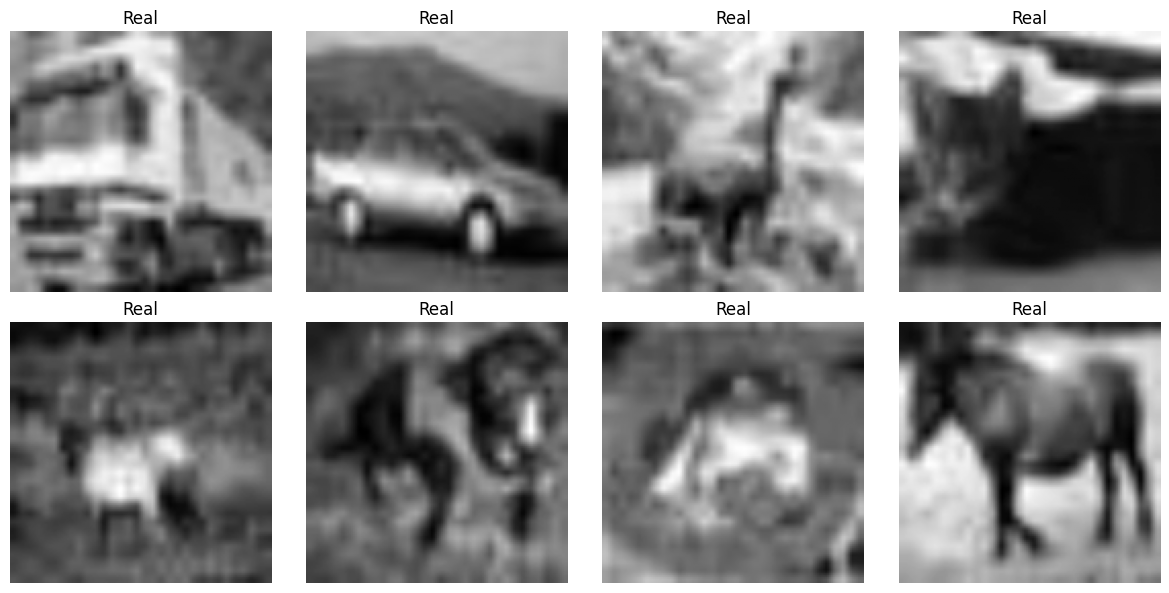

In [11]:
plt.figure(figsize=(12, 6))

for i in range(8):
    
    plt.subplot(2, 4, i + 1)
    
    plt.imshow(X_train_images[i], cmap="gray")
    
    if y_train[i] == 0:
        plt.title("Real")
    else:
        plt.title("Fake")
    
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from skimage.feature import hog

In [13]:
def extract_hog_features(images):
    
    features = []
    
    for image in images:
        
        hog_features = hog(
            image,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys"
        )
        
        features.append(hog_features)
    
    return np.array(features)

In [14]:
X_train = extract_hog_features(X_train_images)
X_test = extract_hog_features(X_test_images)

y_train = np.array(y_train)
y_test = np.array(y_test)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

Training feature shape: (40, 8100)
Testing feature shape: (41, 8100)


In [15]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("SVM model created successfully.")

SVM model created successfully.


In [17]:
svm_model.fit(X_train, y_train)

print("SVM training completed successfully!")

SVM training completed successfully!


In [18]:
y_pred = svm_model.predict(X_test)

print("Actual labels   :", y_test)
print("Predicted labels:", y_pred)

Actual labels   : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1]
Predicted labels: [0 0 0 1 0 0 0 0 1 1 0 0 1 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 1 1 0 0 1 0
 1 1 1 1]


In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.6585365853658537
Accuracy (%): 65.85365853658537


In [20]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Real", "Fake"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Real       0.65      0.71      0.68        21
        Fake       0.67      0.60      0.63        20

    accuracy                           0.66        41
   macro avg       0.66      0.66      0.66        41
weighted avg       0.66      0.66      0.66        41



In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[15  6]
 [ 8 12]]


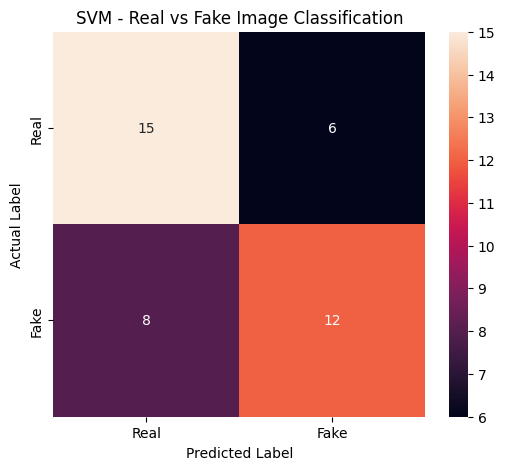

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM - Real vs Fake Image Classification")

plt.show()